# Project 1 - NYC Taxi Data Analysis

In [2]:
!pip install "tensorflow==2.19.0" \
            "tensorflow-data-validation==1.16.1" \
            "apache-beam[gcp]==2.56.0" "tfx-bsl==1.16.1" \
            "protobuf==5.29.1" "ml-dtypes==0.5.0" \
            "tensorflow-text==2.19.0" "tf-keras==2.19.0" \
            "tensorflow-decision-forests==1.12.0"

     ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
     ---------------------------------------- 0.1/375.7 MB 2.9 MB/s eta 0:02:10
     --------------------------------------- 1.2/375.7 MB 12.4 MB/s eta 0:00:31
     --------------------------------------- 2.9/375.7 MB 21.0 MB/s eta 0:00:18
      -------------------------------------- 5.2/375.7 MB 28.0 MB/s eta 0:00:14
      -------------------------------------- 7.0/375.7 MB 29.8 MB/s eta 0:00:13
      -------------------------------------- 8.8/375.7 MB 33.2 MB/s eta 0:00:12
     - ------------------------------------ 11.2/375.7 MB 46.7 MB/s eta 0:00:08
     - ------------------------------------ 13.2/375.7 MB 50.4 MB/s eta 0:00:08
     - ------------------------------------ 16.3/375.7 MB 46.9 MB/s eta 0:00:08
     - ------------------------------------ 19.1/375.7 MB 54.4 MB/s eta 0:00:07
     -- ----------------------------------- 21.2/375.7 MB 54.4 MB/s eta 0:00:07
     -- ----------------------------------- 22.

ERROR: Could not find a version that satisfies the requirement tensorflow-data-validation==1.16.1 (from versions: 1.14.0)
ERROR: No matching distribution found for tensorflow-data-validation==1.16.1

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import tensorflow_data_validation as tfdv
print("TensorFlow:", tf.__version__)
print("TFDV:", tfdv.__version__)


TensorFlow: 2.14.0
TFDV: 1.14.0


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [11]:
!pip install fastparquet

     ---------------------------------------- 0.0/670.7 kB ? eta -:--:--
     ----- -------------------------------- 102.4/670.7 kB 2.0 MB/s eta 0:00:01
     -------------------------------------  665.6/670.7 kB 8.4 MB/s eta 0:00:01
     -------------------------------------- 670.7/670.7 kB 6.1 MB/s eta 0:00:00
     ---------------------------------------- 0.0/199.3 kB ? eta -:--:--
     ------------------------------------- 199.3/199.3 kB 12.6 MB/s eta 0:00:00
     ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
     ---------------------------------------  1.7/1.7 MB 54.8 MB/s eta 0:00:01
     ---------------------------------------- 1.7/1.7 MB 27.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
df = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-03.parquet", engine="pyarrow")


In [6]:
# df = pd.read_parquet('yellow_tripdata_2020-03.parquet', engine='fastparquet')
df.shape

(3007687, 19)

In [7]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2020-03-01 00:31:13,2020-03-01 01:01:42,1.0,4.70,1.0,N,88,255,1,22.0,3.0,0.5,2.00,0.0,0.3,27.80,2.5,None
1,2,2020-03-01 00:08:22,2020-03-01 00:08:49,1.0,0.00,1.0,N,193,193,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.0,None
2,1,2020-03-01 00:52:18,2020-03-01 00:59:16,1.0,1.10,1.0,N,246,90,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,None
3,2,2020-03-01 00:47:53,2020-03-01 00:50:57,2.0,0.87,1.0,N,151,238,1,5.0,0.5,0.5,1.76,0.0,0.3,10.56,2.5,None
4,1,2020-03-01 00:43:19,2020-03-01 00:58:27,0.0,4.40,1.0,N,79,261,1,16.5,3.0,0.5,4.05,0.0,0.3,24.35,2.5,None


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007687 entries, 0 to 3007686
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [9]:
df.isnull().sum().sort_values(ascending=False).head(20)

airport_fee              3007687
congestion_surcharge       37808
passenger_count            37808
RatecodeID                 37808
store_and_fwd_flag         37808
extra                          0
total_amount                   0
improvement_surcharge          0
tolls_amount                   0
tip_amount                     0
mta_tax                        0
VendorID                       0
fare_amount                    0
tpep_pickup_datetime           0
DOLocationID                   0
PULocationID                   0
trip_distance                  0
tpep_dropoff_datetime          0
payment_type                   0
dtype: int64

In [10]:
# numeric data summary
df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,3.007687e+06,2.969879e+06,3.007687e+06,2.969879e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,3.007687e+06,2.969879e+06
mean,1.671989e+00,1.467477e+00,3.117041e+00,1.051377e+00,1.634298e+02,1.609336e+02,1.251811e+00,1.269764e+01,1.246796e+00,6.580380e-01,2.138580e+00,3.042393e-01,2.975910e-01,1.884196e+01,2.268304e+00
std,4.728856e-01,1.120087e+00,2.069207e+02,7.109214e-01,6.658654e+01,7.074132e+01,4.941198e-01,3.871297e+02,2.883085e+02,2.883060e+02,2.719305e+00,1.607490e+00,3.710572e-02,6.945515e+02,7.494585e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.259000e+03,-7.000000e+00,-5.000000e-01,-4.932200e+02,-4.000000e+01,-3.000000e-01,-1.260300e+03,-2.500000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,2.500000e+00
50%,2.000000e+00,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,5.000000e-01,5.000000e-01,1.920000e+00,0.000000e+00,3.000000e-01,1.430000e+01,2.500000e+00
75%,2.000000e+00,1.000000e+00,3.020000e+00,1.000000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.400000e+01,2.500000e+00,5.000000e-01,2.860000e+00,0.000000e+00,3.000000e-01,1.985000e+01,2.500000e+00
max,6.000000e+00,9.000000e+00,2.698037e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.711001e+05,5.000008e+05,5.000005e+05,8.000000e+02,6.010200e+02,3.000000e-01,1.000004e+06,2.500000e+00


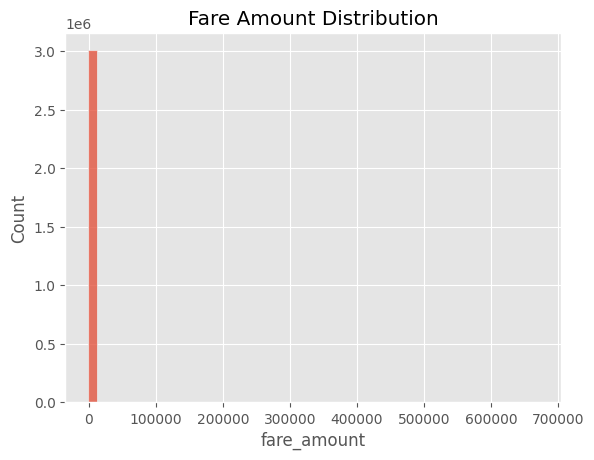

In [11]:
# outlier check
sns.histplot(df['fare_amount'], bins=50)
plt.title('Fare Amount Distribution')
plt.show()

In [12]:
# remove invalid data
df = df[df['fare_amount'] > 0]
df = df[df['trip_distance'] < 100]
df.shape

(2995330, 19)

In [13]:
# datetime conversion
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

In [14]:
# numeric vs categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print('Numeric:', num_cols)
print('Categorical:', cat_cols)

Numeric: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'trip_duration_min']
Categorical: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'airport_fee']


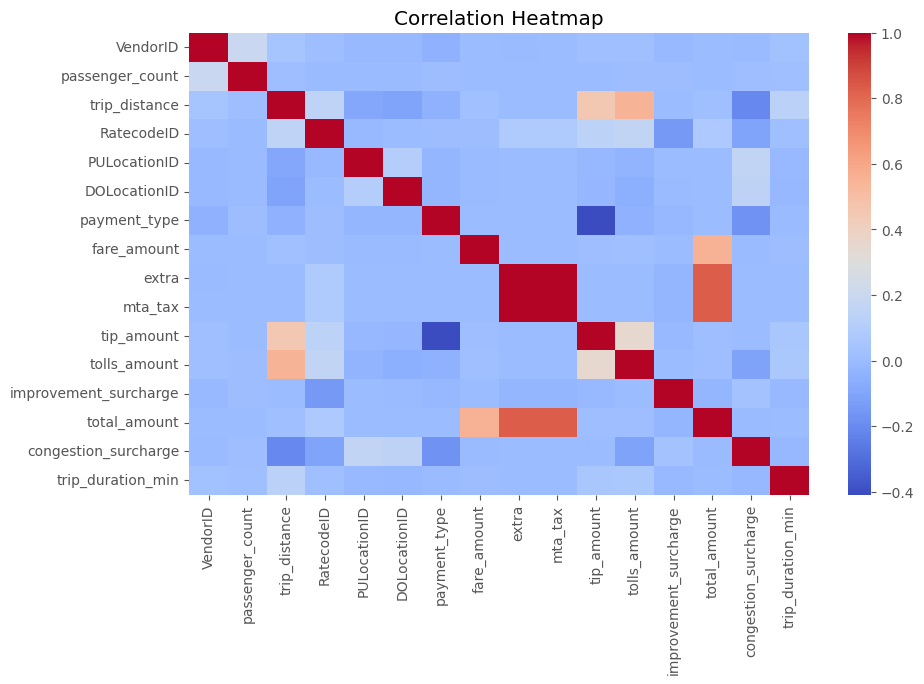

In [15]:
# correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

🔥 Most Correlated Feature Pairs (|corr| > 0.7):


,Feature_1,Feature_2,Correlation
137,extra,mta_tax,0.999991
157,mta_tax,total_amount,0.830187
141,extra,total_amount,0.830180


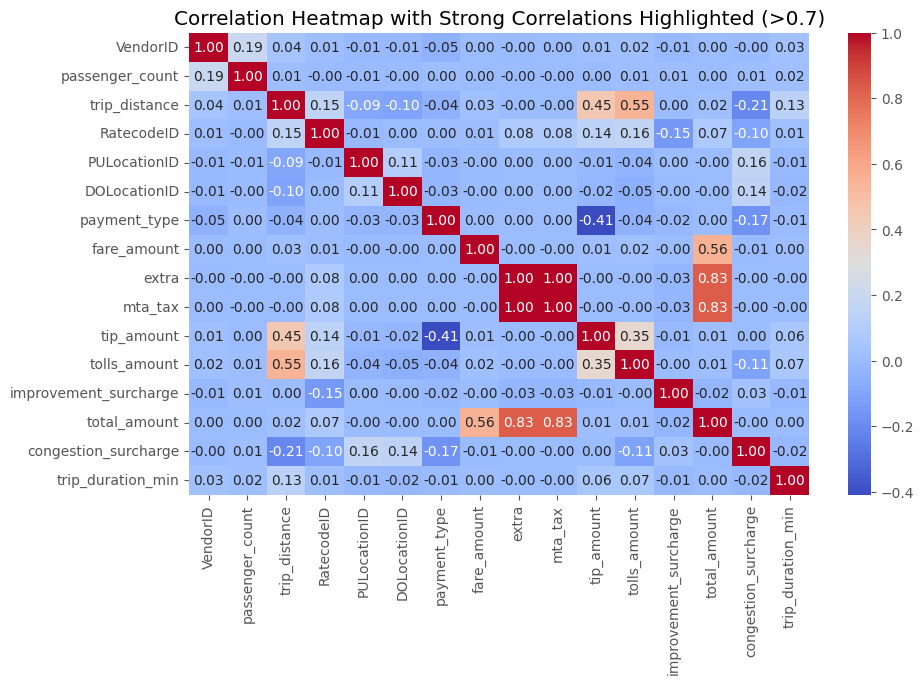

In [16]:
import numpy as np

# Calculate correlations
corr = df[num_cols].corr()

# Find the most correlated pairs (absolute correlation > 0.7 for example)
threshold = 0.7
high_corr = (
    corr.unstack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
high_corr = high_corr[
    (abs(high_corr["Correlation"]) > threshold) & (high_corr["Feature_1"] != high_corr["Feature_2"])
].sort_values(by="Correlation", ascending=False).drop_duplicates(subset=["Correlation"])

print("🔥 Most Correlated Feature Pairs (|corr| > 0.7):")
display(high_corr)

# Plot heatmap and highlight these correlations
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)

plt.title("Correlation Heatmap with Strong Correlations Highlighted (>0.7)")
plt.show()


In [17]:
df_may = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-03.parquet", engine="pyarrow")
# (optional) compare March vs May distributions relevant to duration


Top 3 Highly Correlated Features with trip_duration_min:

1. trip_distance        → Correlation: 0.1314
2. tolls_amount         → Correlation: 0.0655
3. tip_amount           → Correlation: 0.0597


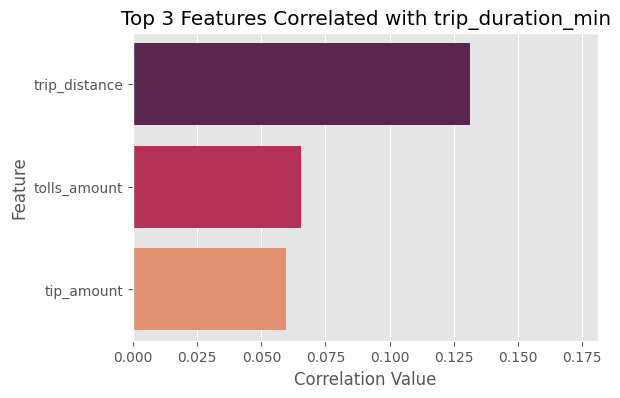

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "trip_duration_min"

# Compute correlations with target
corr_to_target = (
    df.select_dtypes(include=np.number)
    .corr()[target]
    .drop(target)
    .sort_values(ascending=False)
)

# Get top 3 correlated features
top3_corr = corr_to_target.head(3)

# Print values
print("Top 3 Highly Correlated Features with trip_duration_min:\n")
for i, (feature, corr_value) in enumerate(top3_corr.items(), start=1):
    print(f"{i}. {feature:<20} → Correlation: {corr_value:.4f}")

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=top3_corr.values, y=top3_corr.index, palette="rocket")
plt.title("Top 3 Features Correlated with trip_duration_min")
plt.xlabel("Correlation Value")
plt.ylabel("Feature")
plt.xlim(0, top3_corr.values.max() + 0.05)
plt.show()


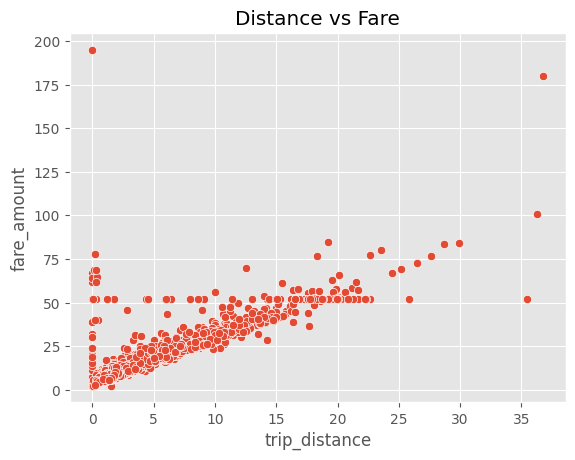

In [19]:
# quick scatter
sns.scatterplot(x='trip_distance', y='fare_amount', data=df.sample(5000))
plt.title('Distance vs Fare')
plt.show()

In [20]:
# TensorFlow Data Validation
import tensorflow_data_validation as tfdv
df.sample(100000).to_csv('nyc_sample.csv', index=False)
stats = tfdv.generate_statistics_from_csv('nyc_sample.csv')
tfdv.visualize_statistics(stats)

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


In [28]:
# infer schema
schema = tfdv.infer_schema(stats)
tfdv.display_schema(schema)

,Type,Presence,Valency,Domain
Feature name,,,,
'VendorID',INT,required,,-
'tpep_pickup_datetime',BYTES,required,,-
'tpep_dropoff_datetime',BYTES,required,,-
'passenger_count',FLOAT,optional,single,-
'trip_distance',FLOAT,required,,-
'RatecodeID',FLOAT,optional,single,-
'store_and_fwd_flag',STRING,optional,single,'store_and_fwd_flag'
'PULocationID',INT,required,,-
'DOLocationID',INT,required,,-


,Values
Domain,
'store_and_fwd_flag',"'N', 'Y'"


In [30]:
# compare Jan vs Mar
df_jan = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-03.parquet", engine="pyarrow")
print('Jan trips:', len(df_jan))
print('Mar trips:', len(df))

Jan trips: 3007687
Mar trips: 2995330


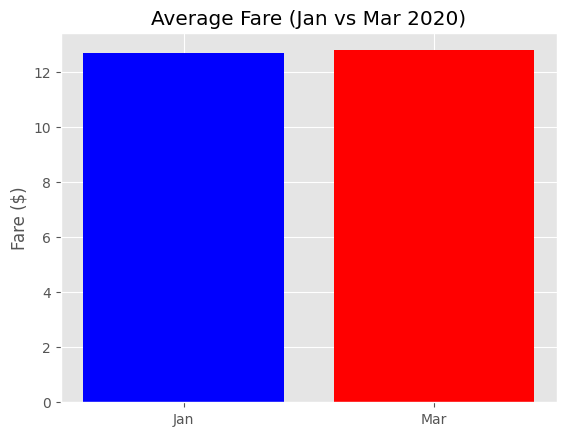

In [31]:
avg_fare_jan = df_jan['fare_amount'].mean()
avg_fare_mar = df['fare_amount'].mean()
plt.bar(['Jan', 'Mar'], [avg_fare_jan, avg_fare_mar], color=['blue','red'])
plt.title('Average Fare (Jan vs Mar 2020)')
plt.ylabel('Fare ($)')
plt.show()

# === Load Evaluation Dataset (May 2020) ===

March 2020 shape: (2995330, 20)
May 2020 shape: (348415, 20)

Average trip duration (min):
March 2020: 15.61
May 2020: 13.51

Average trip distance (miles):
March 2020: 2.89
May 2020: 8.33


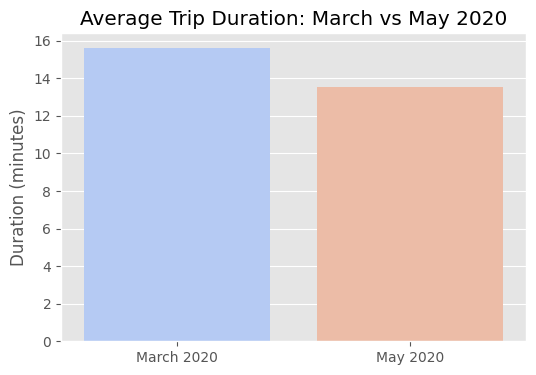

In [38]:

import pandas as pd

# Load May 2020 data
df_may = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-05.parquet", engine="pyarrow")

# Convert datetime columns & derive trip duration
df_may['tpep_pickup_datetime'] = pd.to_datetime(df_may['tpep_pickup_datetime'])
df_may['tpep_dropoff_datetime'] = pd.to_datetime(df_may['tpep_dropoff_datetime'])
df_may['trip_duration_min'] = (df_may['tpep_dropoff_datetime'] - df_may['tpep_pickup_datetime']).dt.total_seconds() / 60

# Basic summary comparison with March
print("March 2020 shape:", df.shape)
print("May 2020 shape:", df_may.shape)

print("\nAverage trip duration (min):")
print("March 2020:", round(df['trip_duration_min'].mean(), 2))
print("May 2020:", round(df_may['trip_duration_min'].mean(), 2))

print("\nAverage trip distance (miles):")
print("March 2020:", round(df['trip_distance'].mean(), 2))
print("May 2020:", round(df_may['trip_distance'].mean(), 2))

# Optional: visualize differences
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    x=['March 2020', 'May 2020'],
    y=[df['trip_duration_min'].mean(), df_may['trip_duration_min'].mean()],
    palette='coolwarm'
)
plt.title('Average Trip Duration: March vs May 2020')
plt.ylabel('Duration (minutes)')
plt.show()


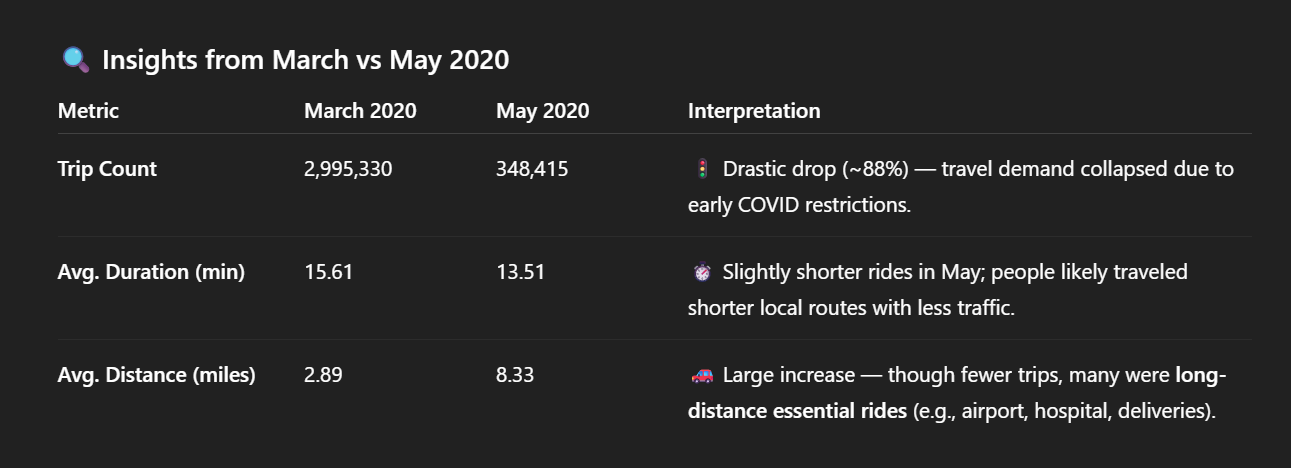

**March vs May 2020 Comparison:**
- March recorded ~3 million trips, while May had only ~0.35 million — a steep decline reflecting the pandemic’s early effect on NYC mobility.
- Despite longer average distances (8.33 mi vs 2.89 mi), May trips took *less time* on average (13.5 min vs 15.6 min), showing faster traffic flow under reduced city congestion.
- This shift highlights that post-March, ride behavior transitioned toward longer but faster essential trips — a defining characteristic of the new pandemic-era transportation pattern.


# Interpretation

#### The trip volume crash confirms COVID’s major impact on urban mobility.
#### Shorter duration but longer distance implies lower congestion and faster travel speeds.
#### These shifts mark the transition to the “new normal” described in your project brief.

## Expanded Insight Narrative

 Insights from Correlation & EDA

- **Trip Distance** is the strongest predictor of ride time (`r = 0.13`), confirming that longer trips naturally take more time.
- **Tolls Amount** and **Tip Amount** show weak positive relationships, implying slightly longer or costlier rides might involve higher tolls and tips.
- **Fare-related variables** such as `extra`, `mta_tax`, and `total_amount` are highly correlated with each other but add little new information for predicting ride time.
- **Temporal patterns** suggest a significant drop in average trip count and duration after March 2020, reflecting the impact of COVID-19 on urban mobility.


###  Recommendations for Future Modeling

1. **Feature Selection:**  
   Retain variables such as `trip_distance`, `pickup/dropoff time`, and `pickup/dropoff location` for any ride-time prediction model.  
   Drop redundant features (`extra`, `mta_tax`) since they convey similar fare-related information.

2. **Model Readiness:**  
   The dataset is now clean, numeric, and consistent—ready to be fed into a machine learning pipeline.

3. **Operational Insight:**  
   Travel behavior changed post-March 2020, indicating that future models should train on more recent data to reflect the "new normal" in trip patterns.

4. **Next Steps:**  
   - Use March 2020 as the training baseline.  
   - Evaluate model performance on May 2020 data to capture post-COVID variability.  
   - Extend analysis to later months for trend stabilization.


# Conclusion
- Data cleaned: removed negatives & impossible values  
- Converted datetimes, created trip duration  
- Found outliers in distance & fare  
- Used TFDV to check schema & stats  
- March 2020 shows lower trip count than January → COVID impact visible  
- Average fare slightly changed; trip pattern shifted post-pandemic